# Erste Implementierung eines NN mit erster Methode und ersten Tests 

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
 
np.random.seed(42)


In [5]:
# Datensatz laden
housing = fetch_california_housing(as_frame=True)

X = housing.data.values
y = housing.target.values

# Train / Test // Hier Train 72%, 20% test und 8% Val
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


# Train / Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42)


# Standardisierung. Damit nicht machne Werte Skala von 1-10 und andere 1-10.000 haben
scaler = StandardScaler()
# fit → lernt Statistik
# transform → wendet Statistik an
X_train_s = scaler.fit_transform(X_train) # Standardisierung für 72% der Trainingsdaten Hier  fit = Feature egänzung um Mittelwert und std  Transform = (x - Mittelwert / std -> 
X_val_s   = scaler.transform(X_val)  # Standardisierung für 8% der Trainingsdaten
X_test_s  = scaler.transform(X_test) # Standardisierung für 20% der Trainingsdaten


In [6]:
nn = MLPRegressor(
    hidden_layer_sizes=(64, 32),  # 2 Hidden Layers, Je Mehr desto Präziser -> Aber auch Overfitting Risiko
    activation='relu',            # ReLU-Aktivierung. Aktivierungsfunktion der Hiddenlayer ReLU (max(0,X)) -> nicht kleiner als 0
    solver='adam',                # Adam-Optimierer // Standard Gradient -> passt die Gewichtung des Netzes an
    learning_rate_init=0.0005,     # Lernrate // Apassung wie Stark das Gewicht pro Schritt geamcht wir, je Höher desto Schneller 0.001 Standard
    max_iter=500,                 # Max. Epochen die durchgelaufen werden
    early_stopping=False,          # Early Stopping aktiv // Sobald training Präzision sich nicht mehr verbessert, wird gestoppt
    #validation_fraction=0.1,     # Val-Anteil // W
    #n_iter_no_change=20,          # Wenn der Val Score x Epochen nciht besser wird, dann Stopt er
    batch_size=64,                # Verarbeitung in mini Batches, also SChritt für Schritt
    random_state=42)              # Reproduzierbarkeit wird sichergestellt
nn.fit(X_train_s, y_train)

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",64
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.0005
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


# Ergebnisse mit Testdaten

In [7]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred_val = nn.predict(X_val_s)

rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2_val = r2_score(y_val, y_pred_val)

print("Validation RMSE:", rmse_val)
print("Validation R²:", r2_val)

Validation RMSE: 0.5424070474597221
Validation R²: 0.7895678734837951


# Ergebnisse mit Validierungsdaten

In [8]:
y_pred_test = nn.predict(X_test_s)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("Test RMSE:", rmse_test)
print("Test R²:", r2_test)

Test RMSE: 0.5161650120559583
Test R²: 0.7966846045053966


# Einfachere Lineare reggresion

In [9]:
from sklearn.linear_model import LinearRegression
lin = LinearRegression()
lin.fit(X_train_s, y_train)
y_pred_lr = lin.predict(X_test_s)

# Auswertung beider Methoden

NN-Methode 

In [10]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Vorhersage auf Testdaten
y_pred_nn = nn.predict(X_test_s)

# Kennzahlen berechnen
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn = r2_score(y_test, y_pred_nn)

print("Neural Network Ergebnisse")
print("RMSE:", rmse_nn)
print("R2:", r2_nn)

Neural Network Ergebnisse
RMSE: 0.5161650120559583
R2: 0.7966846045053966


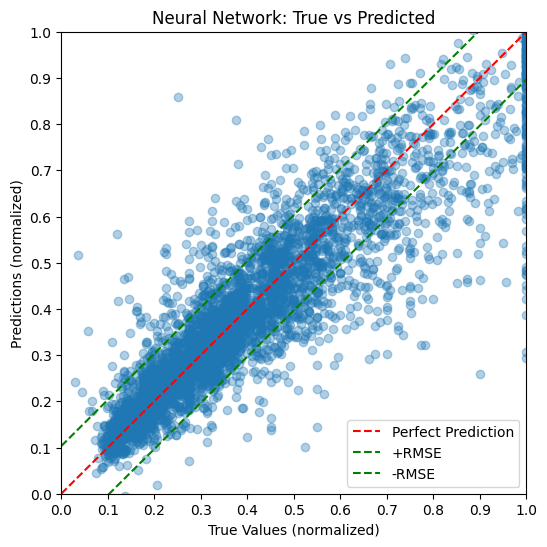

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Skalierung für Plot (0–5 → 0–1)
y_test_scaled = y_test / 5
y_pred_nn_scaled = y_pred_nn / 5
rmse_nn_scaled = rmse_nn / 5

ticks = np.arange(0,1.1,0.1)

plt.figure(figsize=(6,6))

plt.scatter(y_test_scaled, y_pred_nn_scaled, alpha=0.35)

x_line = np.linspace(0,1,100)

plt.plot(x_line, x_line, "r--", label="Perfect Prediction")
plt.plot(x_line, x_line + rmse_nn_scaled, "g--", label="+RMSE")
plt.plot(x_line, x_line - rmse_nn_scaled, "g--", label="-RMSE")

plt.xlabel("True Values (normalized)")
plt.ylabel("Predictions (normalized)")
plt.title("Neural Network: True vs Predicted")

plt.xlim(0,1)
plt.ylim(0,1)

plt.xticks(ticks)
plt.yticks(ticks)

plt.legend()

plt.show()

Reggresions-Methode

In [12]:
# Vorhersage
y_pred_lr = lin.predict(X_test_s)

# Kennzahlen
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Lineare Regression Ergebnisse")
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Lineare Regression Ergebnisse
RMSE: 0.7456382527122102
R2: 0.5757229894333724


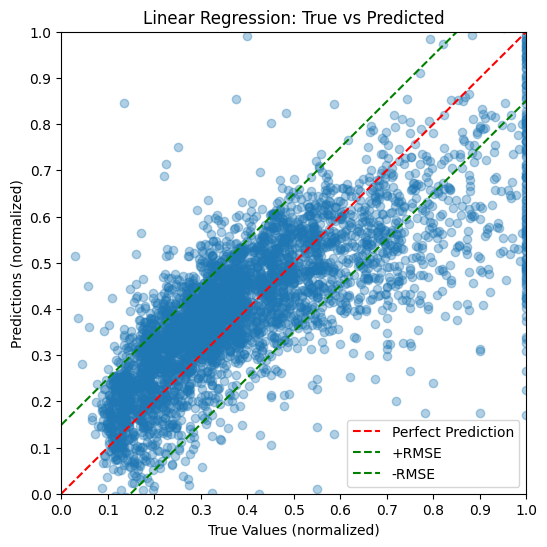

In [13]:
y_pred_lr_scaled = y_pred_lr / 5
rmse_lr_scaled = rmse_lr / 5

plt.figure(figsize=(6,6))

plt.scatter(y_test_scaled, y_pred_lr_scaled, alpha=0.35)

x_line = np.linspace(0,1,100)

plt.plot(x_line, x_line, "r--", label="Perfect Prediction")
plt.plot(x_line, x_line + rmse_lr_scaled, "g--", label="+RMSE")
plt.plot(x_line, x_line - rmse_lr_scaled, "g--", label="-RMSE")

plt.xlabel("True Values (normalized)")
plt.ylabel("Predictions (normalized)")
plt.title("Linear Regression: True vs Predicted")

plt.xlim(0,1)
plt.ylim(0,1)

plt.xticks(ticks)
plt.yticks(ticks)

plt.legend()

plt.show()

# Direkter Vergleich 

In [14]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Neural Network","Linear Regression"],
    "RMSE": [rmse_nn, rmse_lr],
    "R2": [r2_nn, r2_lr]
})

comparison

,Model,RMSE,R2
0,Neural Network,0.516165,0.796685
1,Linear Regression,0.745638,0.575723


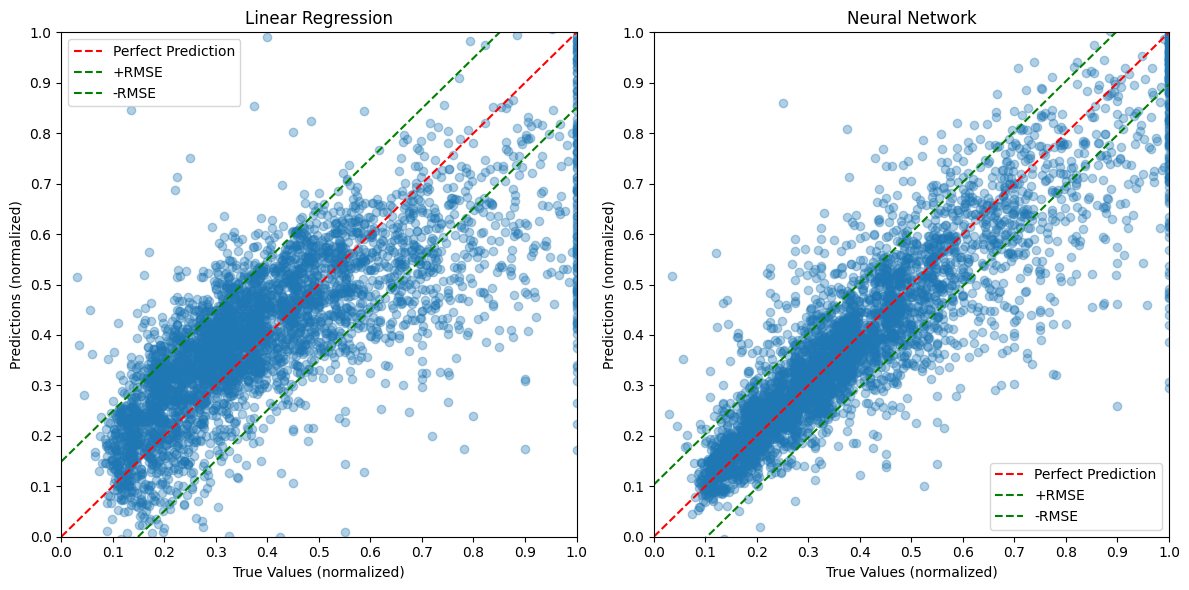

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Skalierung
y_test_scaled = y_test / 5
y_pred_lr_scaled = y_pred_lr / 5
y_pred_nn_scaled = y_pred_nn / 5

rmse_lr_scaled = rmse_lr / 5
rmse_nn_scaled = rmse_nn / 5

ticks = np.arange(0,1.1,0.1)
x_line = np.linspace(0,1,100)

fig, axes = plt.subplots(1,2, figsize=(12,6))

# Linear Regression
axes[0].scatter(y_test_scaled, y_pred_lr_scaled, alpha=0.35)

axes[0].plot(x_line, x_line, "r--", label="Perfect Prediction")
axes[0].plot(x_line, x_line + rmse_lr_scaled, "g--", label="+RMSE")
axes[0].plot(x_line, x_line - rmse_lr_scaled, "g--", label="-RMSE")

axes[0].set_xlabel("True Values (normalized)")
axes[0].set_ylabel("Predictions (normalized)")
axes[0].set_title("Linear Regression")

axes[0].set_xlim(0,1)
axes[0].set_ylim(0,1)

axes[0].set_xticks(ticks)
axes[0].set_yticks(ticks)

axes[0].legend()


# Neurales Netz
axes[1].scatter(y_test_scaled, y_pred_nn_scaled, alpha=0.35)

axes[1].plot(x_line, x_line, "r--", label="Perfect Prediction")
axes[1].plot(x_line, x_line + rmse_nn_scaled, "g--", label="+RMSE")
axes[1].plot(x_line, x_line - rmse_nn_scaled, "g--", label="-RMSE")

axes[1].set_xlabel("True Values (normalized)")
axes[1].set_ylabel("Predictions (normalized)")
axes[1].set_title("Neural Network")

axes[1].set_xlim(0,1)
axes[1].set_ylim(0,1)

axes[1].set_xticks(ticks)
axes[1].set_yticks(ticks)

axes[1].legend()

plt.tight_layout()
plt.show()

# Direkter Vergleich mit Testdaten

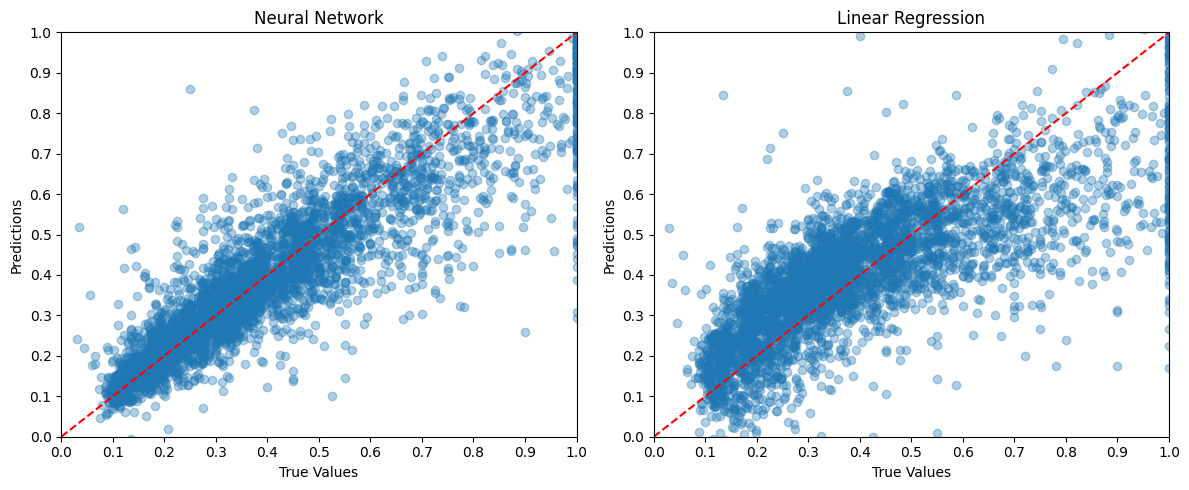

In [16]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

# Neural Network
axes[0].scatter(y_test_scaled, y_pred_nn_scaled, alpha=0.35)
axes[0].plot([0,1],[0,1],"r--")
axes[0].set_title("Neural Network")
axes[0].set_xlabel("True Values")
axes[0].set_ylabel("Predictions")
axes[0].set_xlim(0,1)
axes[0].set_ylim(0,1)
axes[0].set_xticks(ticks)
axes[0].set_yticks(ticks)

# Linear Regression
axes[1].scatter(y_test_scaled, y_pred_lr_scaled, alpha=0.35)
axes[1].plot([0,1],[0,1],"r--")
axes[1].set_title("Linear Regression")
axes[1].set_xlabel("True Values")
axes[1].set_ylabel("Predictions")
axes[1].set_xlim(0,1)
axes[1].set_ylim(0,1)
axes[1].set_xticks(ticks)
axes[1].set_yticks(ticks)

plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Vorhersagen auf Testdaten
y_pred_nn = nn.predict(X_test_s)
y_pred_lr = lin.predict(X_test_s)

# RMSE
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# R2
r2_nn = r2_score(y_test, y_pred_nn)
r2_lr = r2_score(y_test, y_pred_lr)

results = pd.DataFrame({
    "Model": ["Neural Network","Linear Regression"],
    "RMSE": [rmse_nn, rmse_lr],
    "RMSE_normalized": [rmse_nn/5, rmse_lr/5],
    "R2": [r2_nn, r2_lr]
})

results

,Model,RMSE,RMSE_normalized,R2
0,Neural Network,0.516165,0.103233,0.796685
1,Linear Regression,0.745638,0.149128,0.575723


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd


# 1) Lineare Regression
lin = LinearRegression()
lin.fit(X_train_s, y_train)

# Validierung
y_pred_val_lr = lin.predict(X_val_s)
rmse_val_lr = np.sqrt(mean_squared_error(y_val, y_pred_val_lr))
r2_val_lr = r2_score(y_val, y_pred_val_lr)

# Test
y_pred_test_lr = lin.predict(X_test_s)
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))
r2_test_lr = r2_score(y_test, y_pred_test_lr)


# 2) Neurales Netz / MLP
nn = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.0005,
    max_iter=500,
    early_stopping=False,
    batch_size=64,
    random_state=42
)

nn.fit(X_train_s, y_train)

# Validierung
y_pred_val_nn = nn.predict(X_val_s)
rmse_val_nn = np.sqrt(mean_squared_error(y_val, y_pred_val_nn))
r2_val_nn = r2_score(y_val, y_pred_val_nn)

# Test
y_pred_test_nn = nn.predict(X_test_s)
rmse_test_nn = np.sqrt(mean_squared_error(y_test, y_pred_test_nn))
r2_test_nn = r2_score(y_test, y_pred_test_nn)


# 3) Vergleichstabelle

results = pd.DataFrame({
    "Model": ["Linear Regression", "Neural Network"],
    "Validation RMSE": [rmse_val_lr, rmse_val_nn],
    "Validation R2": [r2_val_lr, r2_val_nn],
    "Test RMSE": [rmse_test_lr, rmse_test_nn],
    "Test R2": [r2_test_lr, r2_test_nn]
})

print(results)

               Model  Validation RMSE  Validation R2  Test RMSE   Test R2
0  Linear Regression         0.743998       0.604082   0.745638  0.575723
1     Neural Network         0.542407       0.789568   0.516165  0.796685
